# Exploratory microRNA Network Analysis

**Author:** Ali Farzaneh

This notebook constructs an exploratory microRNA–microRNA network for the microRNAs showing significant age-dependent associations with incident heart failure. Network connections are based on overlap in supported target genes.

## Loading Required libraries

In [1]:
libs <- c(
    "readr",
    "dplyr",
    "igraph"
)

suppressPackageStartupMessages(
    invisible(lapply(libs, library, character.only = TRUE))
)

## Defining Input and Output Directories

In [2]:
result_dir <- "results/network"

if (!dir.exists(result_dir)) {
    dir.create(result_dir, recursive = TRUE)
}

## Load and Prepare microRNA Target Data

Target-gene interactions were retained when experimental validation information was available and the interaction was additionally supported by at least one of TargetScan or miRDB.

In [3]:
mir_target <- readr::read_csv(
    "data/miRWalk_miRNA_targets.csv",
    show_col_types = FALSE
) %>%
    filter(
        !is.na(validated),
        validated != ""
    ) %>%
    mutate(
        n_tools = rowSums(
            across(c(TargetScan, miRDB)),
            na.rm = TRUE
        )
    ) %>%
    filter(n_tools > 0)

dim(mir_target)

[1] 1151   22

## miRNA - miRNA network
Construct the microRNA–microRNA Network

In [4]:
# microRNAs represented in the filtered target-gene dataset
mir <- unique(mir_target$mirnaid)
n <- length(mir)
n

[1] 16

In [5]:
# Initialize pairwise Jaccard similarity matrix
jaccard_mat <- matrix(
    0,
    nrow = n,
    ncol = n,
    dimnames = list(mir, mir)
)

### Pairwise Target-Gene Similarity

Pairwise similarity between microRNAs was quantified using the Jaccard index based on their supported target-gene sets.

In [6]:
target_sets <- split(
    mir_target$genesymbol,
    mir_target$mirnaid
)

target_sets <- lapply(target_sets, unique)

In [7]:
for (i in seq_len(n)) {
    for (k in seq_len(n)) {

        targets_i <- target_sets[[mir[i]]]
        targets_k <- target_sets[[mir[k]]]

        n_intersection <- length(
            intersect(targets_i, targets_k)
        )

        n_union <- length(
            union(targets_i, targets_k)
        )

        jaccard_mat[i, k] <- if (
            n_union > 0
        ) {
            n_intersection / n_union
        } else {
            NA_real_
        }
    }
}

### Network Construction

In [8]:
# Createing graph: nodes = miRNAs, edges weighted by Jaccard index
adj_mat <- jaccard_mat
adj_mat[adj_mat <=0 ] <- 0
diag(adj_mat) <- 0


In [9]:
g <- igraph::graph_from_adjacency_matrix(
    adjmatrix = adj_mat,
    mode = "undirected",
    weighted = TRUE,
    diag = FALSE
)

V(g)$name <- gsub(pattern = "hsa-", replacement = "", V(g)$name)

In [10]:
g <-  graph_from_adjacency_matrix(adjmatrix = adj_mat, mode = 'undirected', weighted = TRUE, diag = FALSE)
V(g)$name <- gsub(pattern = "hsa-", replacement = "", x = mir)

### Node and Edge Attributes

In [11]:
# Edge width reflects Jaccard similarity
E(g)$width <- E(g)$weight * 20

# Node size reflects the number of unique supported target genes
V(g)$size <- sapply(mir, function(m) length(unique(mir_target[mir_target$mirnaid== m, ]$genesymbol)))/10 + 8

## Community Detection

In [12]:
# Identify network communities using the Walktrap algorithm
communities <- cluster_walktrap(g)

V(g)$community <- membership(communities)

## Network Visualization

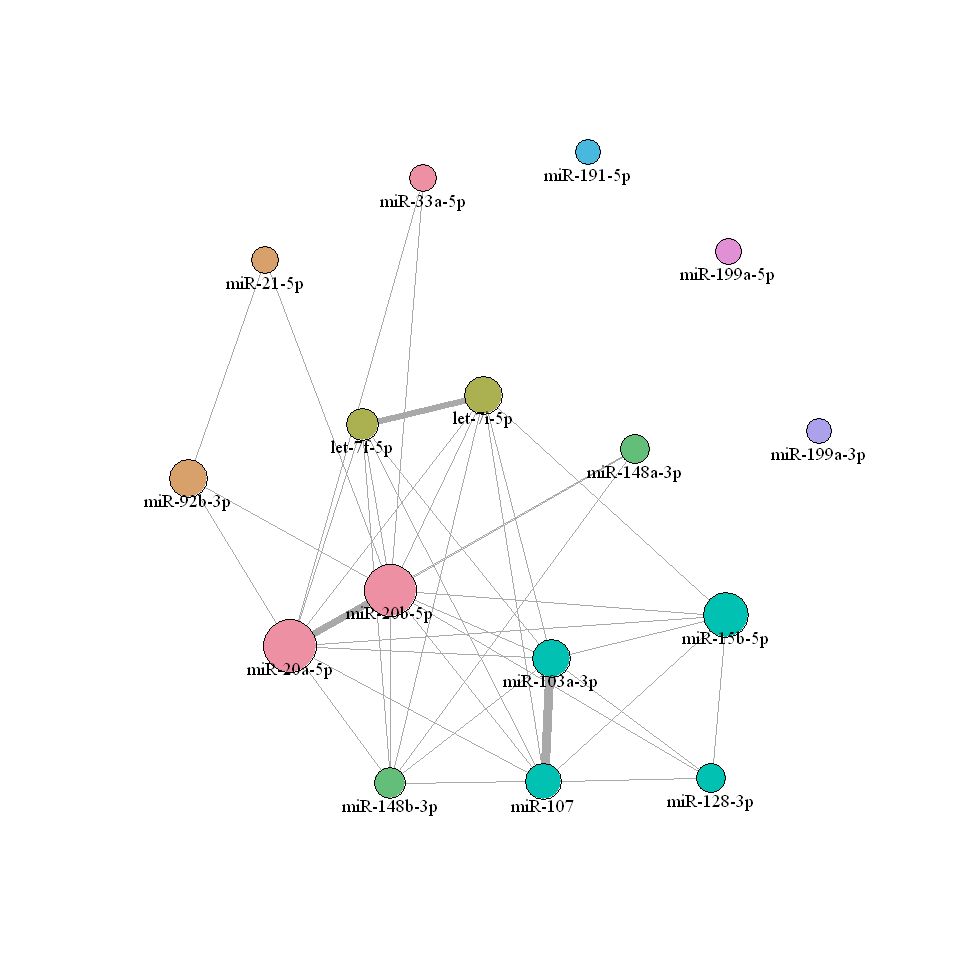

In [13]:
options(
    repr.plot.width = 8,
    repr.plot.height = 8
)

n_communities <- length(unique(V(g)$community))

community_palette <- hcl.colors(
    n_communities,
    palette = "Set 2"
)

V(g)$color <- community_palette[V(g)$community]

plot(
    g,
    vertex.label.cex = 0.9,
    vertex.label.color = "black",
    vertex.color = V(g)$color,
    vertex.label.degree = pi / 2,
    vertex.label.dist = 1.0,
    edge.width = E(g)$width,
    main = NA
)

Exporting Figure

In [14]:
tiff(
    filename = file.path(
        result_dir,
        "miRNA_shared_target_network.tiff"
    ),
    width = 8,
    height = 8,
    units = "in",
    res = 600,
    compression = "lzw"
)

plot(
    g,
    vertex.label.cex = 0.9,
    vertex.label.color = "black",
    vertex.color = V(g)$color,
    vertex.label.degree = pi / 2,
    vertex.label.dist = 1.0,
    edge.width = E(g)$width,
    main = NA
)

dev.off()

agg_record_63f85a194761 
                      2